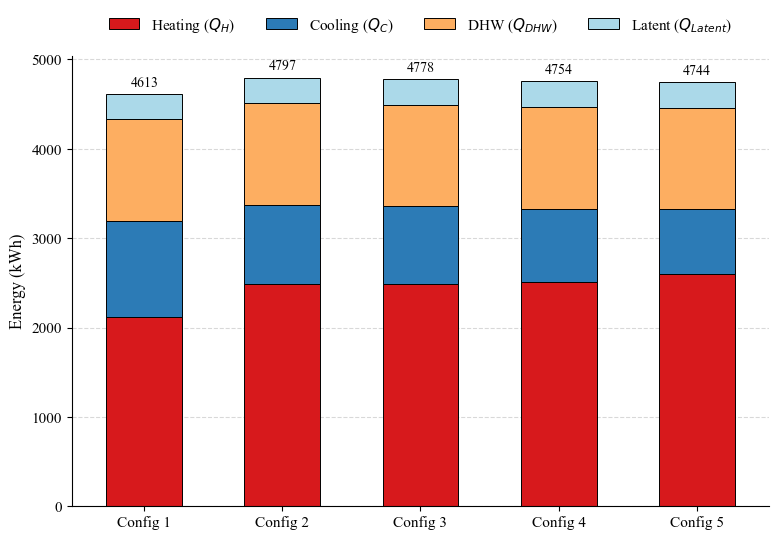

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
data = {
    'Scenario': ['Config 1', 'Config 2', 'Config 3', 'Config 4', 'Config 5'],
    'Heating ($Q_H$)': [2115.5, 2486.0, 2491.0, 2513.0, 2597.402],
    'Cooling ($Q_C$)': [1075.0, 888.0, 864.0, 818.0, 723.6886],
    'DHW ($Q_{DHW}$)': [1138.379, 1138.379, 1138.379, 1138.379, 1138.379],
    'Latent ($Q_{Latent}$)': [284.3281, 284.3281, 284.3281, 284.3281, 284.3281]
}

df = pd.DataFrame(data)
df.set_index('Scenario', inplace=True)

# 2. Academic formatting setup
# Use a serif font to match standard LaTeX documents and ensure text is embedded
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "pdf.fonttype": 42, # Ensures text is editable/embedded in the PDF for publishers
    "ps.fonttype": 42
})

# 3. Create the plot
fig, ax = plt.subplots(figsize=(8, 5.5))

# Colorblind-friendly and print-safe palette (Red, Blue, Orange, Light Blue)
colors = ['#d7191c', '#2c7bb6', '#fdae61', '#abd9e9']

# Added edgecolor and linewidth to make the bars pop sharply when printed
df.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.7, width=0.55)

# 4. Clean up axes and grid
ax.set_ylabel('Energy (kWh)')
ax.set_xlabel('') # Removed 'Simulation Steps' as the x-ticks make it obvious

# Subtle horizontal gridlines pushed behind the bars
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.3)
ax.xaxis.grid(False)

# Remove top and right spines (standard journal format)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 5. Legend placement
# Placed horizontally at the top, without a heavy bounding box
ax.legend(title='', bbox_to_anchor=(0.5, 1.12), loc='upper center', ncol=4, frameon=False)

# 6. Totals on top
totals = df.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 50, f'{total:.0f}', ha='center', va='bottom', color='black', fontsize=10)

# 7. Layout and export
plt.xticks(rotation=0)
plt.tight_layout()

# Export as a vector graphic with a tight bounding box
plt.savefig('thermal_energy_loads_academic.pdf', format='pdf', bbox_inches='tight')
plt.show()

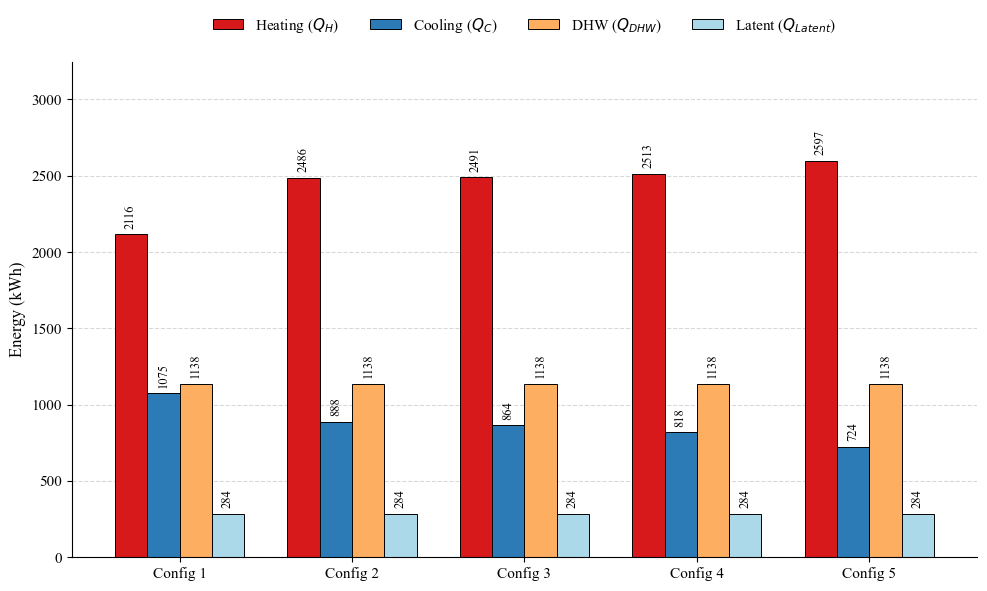

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
data = {
    'Scenario': ['Config 1', 'Config 2', 'Config 3', 'Config 4', 'Config 5'],
    'Heating ($Q_H$)': [2115.5, 2486.0, 2491.0, 2513.0, 2597.4],
    'Cooling ($Q_C$)': [1075.0, 888.0, 864.0, 818.0, 723.7],
    'DHW ($Q_{DHW}$)': [1138.4, 1138.4, 1138.4, 1138.4, 1138.4],
    'Latent ($Q_{Latent}$)': [284.3, 284.3, 284.3, 284.3, 284.3]
}

df = pd.DataFrame(data)
df.set_index('Scenario', inplace=True)

# 2. Academic formatting setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "pdf.fonttype": 42,  # Ensures text is editable/embedded in the PDF
    "ps.fonttype": 42
})

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Colorblind-friendly and print-safe palette
colors = ['#d7191c', '#2c7bb6', '#fdae61', '#abd9e9']

# stacked=False creates the grouped bar chart
df.plot(kind='bar', stacked=False, ax=ax, color=colors, edgecolor='black', linewidth=0.7, width=0.75)

# 4. Clean up axes and grid
ax.set_ylabel('Energy (kWh)')
ax.set_xlabel('')

# Subtle horizontal gridlines pushed behind the bars
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.3)
ax.xaxis.grid(False)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 5. Legend placement
ax.legend(title='', bbox_to_anchor=(0.5, 1.12), loc='upper center', ncol=4, frameon=False)

# 6. Annotate bars with exact values to highlight the trends
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.0f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 4), 
                    textcoords='offset points',
                    fontsize=9, color='black', rotation=90)

# Increase y-axis limit slightly so the annotations don't get clipped
ax.set_ylim(0, df.values.max() * 1.25)

# 7. Layout and export
plt.xticks(rotation=0)
plt.tight_layout()

# Export as a vector graphic
plt.savefig('thermal_energy_grouped_academic.pdf', format='pdf', bbox_inches='tight')
plt.show()